In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
from tqdm import tqdm

In [4]:
train_features = pd.read_csv("../train_features.csv", index_col="id")
test_features = pd.read_csv("../test_features.csv", index_col="id")
train_labels = pd.read_csv("../train_labels.csv", index_col="id")

In [5]:
train_features.head()

,filepath,site
id,,
ZJ000000,train_features/ZJ000000.jpg,S0120
ZJ000001,train_features/ZJ000001.jpg,S0069
ZJ000002,train_features/ZJ000002.jpg,S0009
ZJ000003,train_features/ZJ000003.jpg,S0008
ZJ000004,train_features/ZJ000004.jpg,S0036


In [6]:
test_features.head()

,filepath,site
id,,
ZJ016488,test_features/ZJ016488.jpg,S0082
ZJ016489,test_features/ZJ016489.jpg,S0040
ZJ016490,test_features/ZJ016490.jpg,S0040
ZJ016491,test_features/ZJ016491.jpg,S0041
ZJ016492,test_features/ZJ016492.jpg,S0040


In [7]:
train_labels.head()

,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
id,,,,,,,,
ZJ000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ZJ000001,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZJ000002,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
ZJ000003,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZJ000004,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


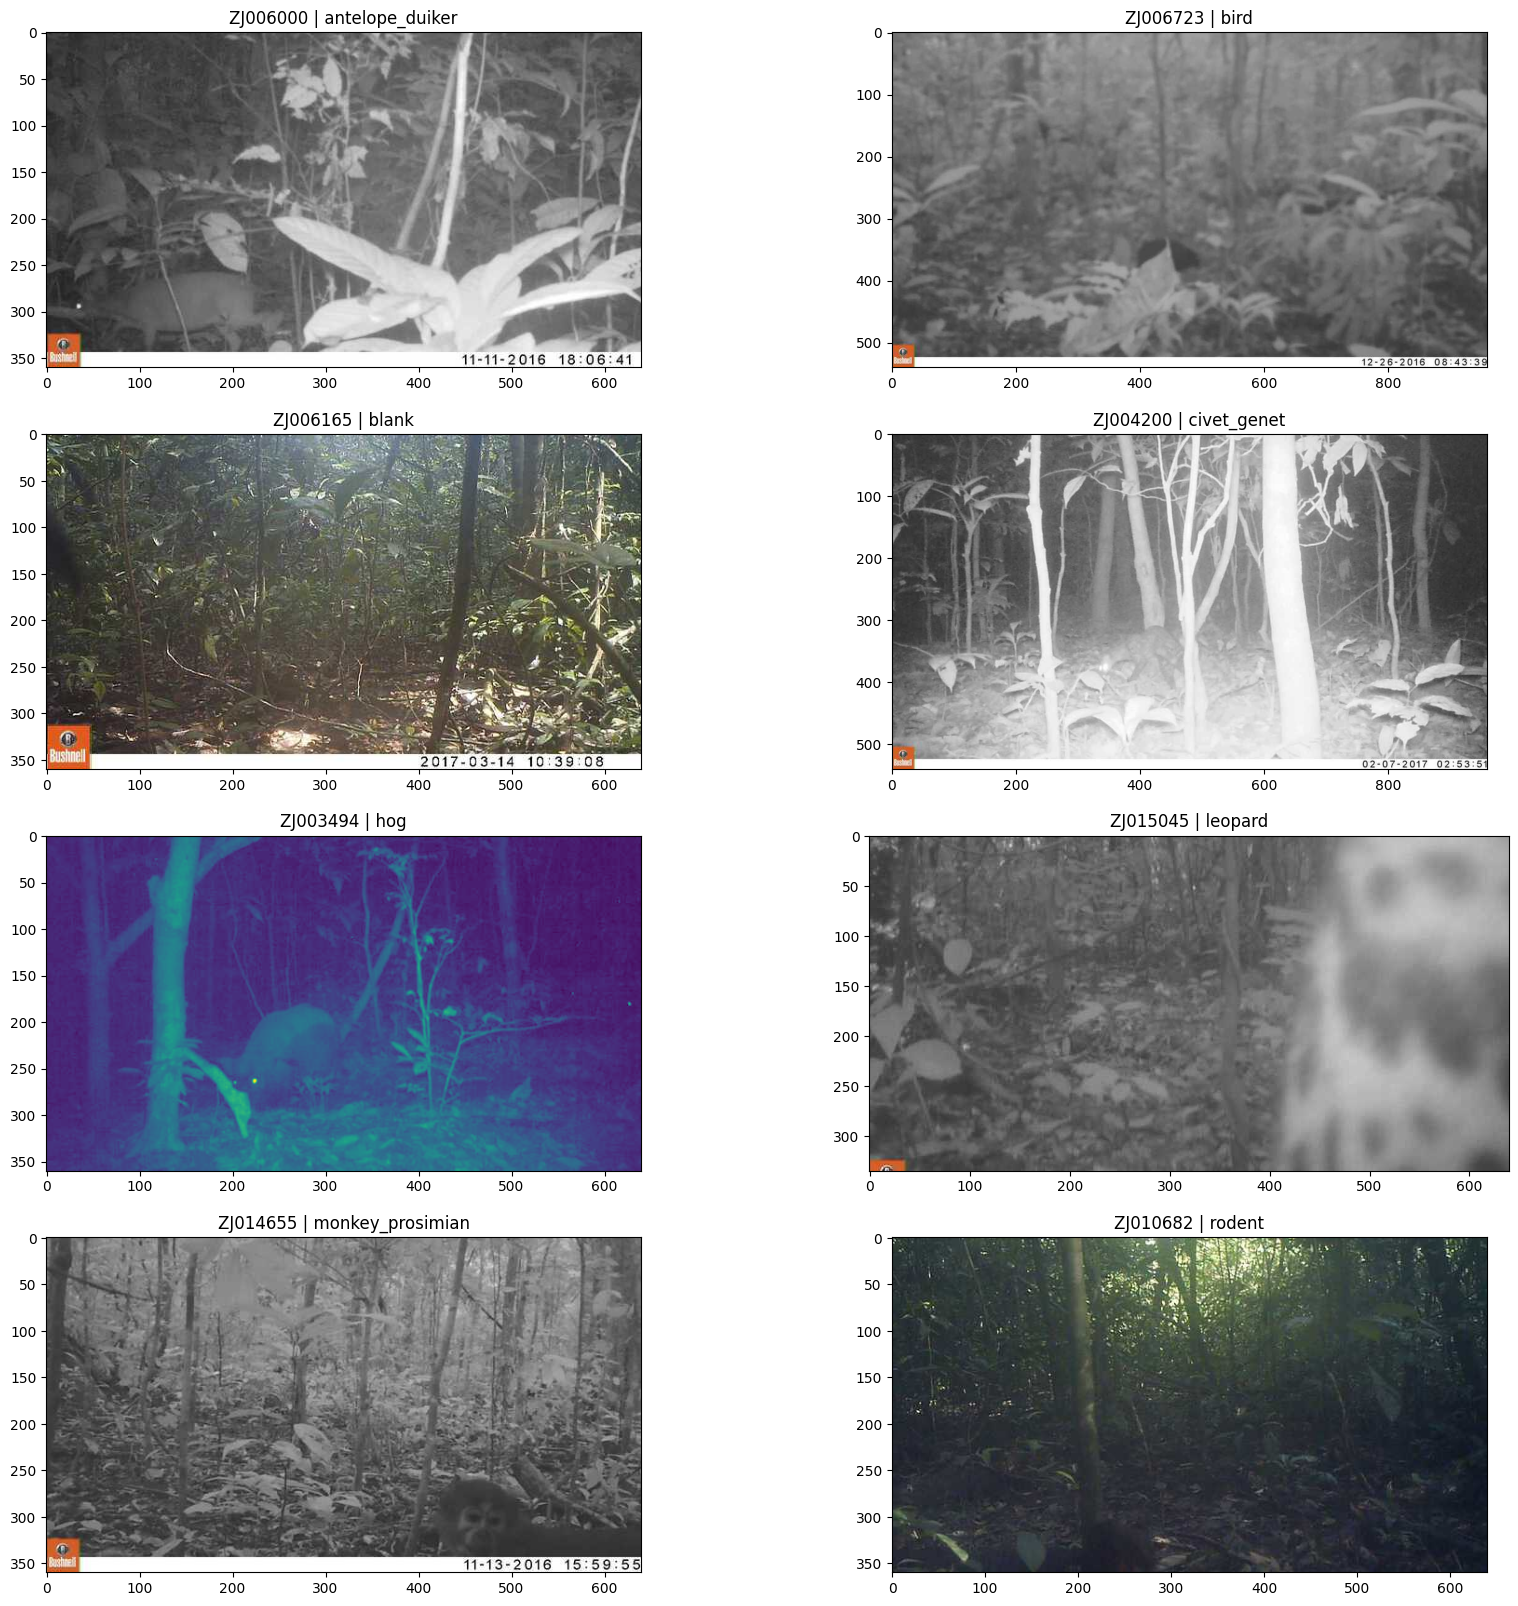

In [ ]:
import matplotlib.image as mpimg

random_state = 42

species_labels = sorted(train_labels.columns.unique())
species_labels

# we'll create a grid with 8 positions, one for each label (7 species, plus blanks)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(20, 20))

# iterate through each species
for species, ax in zip(species_labels, axes.flat):
    # get an image ID for this species
    img_id = (
        train_labels[train_labels.loc[:,species] == 1]
        .sample(1, random_state=random_state)
        .index[0]
    )
    # reads the filepath and returns a numpy array
    img = mpimg.imread('../data/raw/' + train_features.loc[img_id].filepath)
    # plot etc
    ax.imshow(img)
    ax.set_title(f"{img_id} | {species}")

In [16]:
train_labels.sum().sort_values(ascending=False)

monkey_prosimian    2492.0
antelope_duiker     2474.0
civet_genet         2423.0
leopard             2254.0
blank               2213.0
rodent              2013.0
bird                1641.0
hog                  978.0
dtype: float64

In [18]:
img.shape

(360, 640, 3)

In [20]:
import os
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# path to your image directory
image_dir = "../data/raw"

# collect image info
image_info = []

# supported extensions
valid_ext = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff")

for root, _, files in os.walk(image_dir):
    for file in tqdm(files):
        if file.lower().endswith(valid_ext):
            path = os.path.join(root, file)

            try:
                with Image.open(path) as img:
                    width, height = img.size

                    image_info.append({
                        "filename": file,
                        "width": width,
                        "height": height,
                        "aspect_ratio": width / height,
                        "pixels": width * height
                    })

            except Exception as e:
                print(f"Error reading {path}: {e}")

# dataframe
df_images = pd.DataFrame(image_info)

# ===== summary =====
print("Number of images:", len(df_images))

print("\nWidth summary")
print(df_images["width"].describe())

print("\nHeight summary")
print(df_images["height"].describe())

print("\nPixels summary")
print(df_images["pixels"].describe())

0it [00:00, ?it/s]
100%|██████████| 16489/16489 [00:01<00:00, 12970.53it/s]

Number of images: 20952

Width summary
count    20952.000000
mean       745.211913
std        200.338654
min        160.000000
25%        640.000000
50%        640.000000
75%        960.000000
max        960.000000
Name: width, dtype: float64

Height summary
count    20952.000000
mean       420.121229
std        106.936168
min         95.000000
25%        360.000000
50%        360.000000
75%        540.000000
max        540.000000
Name: height, dtype: float64

Pixels summary
count     20952.000000
mean     334378.818251
std      158321.715014
min       15200.000000
25%      230400.000000
50%      230400.000000
75%      518400.000000
max      518400.000000
Name: pixels, dtype: float64


In [22]:
df_images.sort_values('pixels')

,filename,width,height,aspect_ratio,pixels
6746,ZJ002282.jpg,160,95,1.684211,15200
19025,ZJ014561.jpg,160,120,1.333333,19200
12709,ZJ008245.jpg,160,120,1.333333,19200
3167,ZJ019655.jpg,160,120,1.333333,19200
19153,ZJ014689.jpg,160,120,1.333333,19200
...,...,...,...,...,...
22,ZJ016510.jpg,960,540,1.777778,518400
2,ZJ016490.jpg,960,540,1.777778,518400
20950,ZJ016486.jpg,960,540,1.777778,518400
1,ZJ016489.jpg,960,540,1.777778,518400


# train section

In [23]:
from sklearn.model_selection import train_test_split

frac = 0.2

y = train_labels.sample(frac=frac, random_state=1)
x = train_features.loc[y.index].filepath.to_frame()

# note that we are casting the species labels to an indicator/dummy matrix
x_train, x_eval, y_train, y_eval = train_test_split(
    x, y, stratify=y, test_size=0.25
)

In [24]:
x_train.head()

,filepath
id,
ZJ011961,train_features/ZJ011961.jpg
ZJ000604,train_features/ZJ000604.jpg
ZJ010815,train_features/ZJ010815.jpg
ZJ004586,train_features/ZJ004586.jpg
ZJ015781,train_features/ZJ015781.jpg


In [25]:
y_train.head()

,antelope_duiker,bird,blank,civet_genet,hog,leopard,monkey_prosimian,rodent
id,,,,,,,,
ZJ011961,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
ZJ000604,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
ZJ010815,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
ZJ004586,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
ZJ015781,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [26]:
x_train.shape, y_train.shape, x_eval.shape, y_eval.shape

((2473, 1), (2473, 8), (825, 1), (825, 8))

In [28]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms


class ImagesDataset(Dataset):
    """Reads in an image, transforms pixel values, and serves
    a dictionary containing the image id, image tensors, and label.
    """

    def __init__(self, x_df, y_df=None):
        self.data = x_df
        self.label = y_df
        self.transform = transforms.Compose(
            [
                transforms.Resize((224, 224)),
                transforms.ToTensor(),
                transforms.Normalize(
                    mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)
                ),
            ]
        )

    def __getitem__(self, index):
        image = Image.open('../data/raw/' + self.data.iloc[index]["filepath"]).convert("RGB")
        image = self.transform(image)
        image_id = self.data.index[index]
        # if we don't have labels (e.g. for test set) just return the image and image id
        if self.label is None:
            sample = {"image_id": image_id, "image": image}
        else:
            label = torch.tensor(self.label.iloc[index].values, 
                                 dtype=torch.float)
            sample = {"image_id": image_id, "image": image, "label": label}
        return sample

    def __len__(self):
        return len(self.data)

In [29]:
from torch.utils.data import DataLoader

train_dataset = ImagesDataset(x_train, y_train)
train_dataloader = DataLoader(train_dataset, batch_size=32)

## Modeling

In [43]:
from torch import nn
import torchvision.models as models


model = models.efficientnet_b3(pretrained=True)
model.classifier = nn.Sequential(
    nn.Linear(1536, 100),  # dense layer takes a 1536-dim input and outputs 100-dim
    nn.ReLU(inplace=True),  # ReLU activation introduces non-linearity
    nn.Dropout(0.2),  # common technique to mitigate overfitting
    nn.Linear(
        100, 8
    ),  # final dense layer outputs 8-dim corresponding to our target classes
)

d:\myprojects\conser-vision\.venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\myprojects\conser-vision\.venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B3_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [44]:
model

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 40, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(40, 40, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=40, bias=False)
            (1): BatchNorm2d(40, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(40, 10, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(10, 40, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
        

In [40]:
import torch.optim as optim

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [45]:
num_epochs = 20

tracking_loss = {}

for epoch in range(1, num_epochs + 1):
    print(f"Starting epoch {epoch}")

    # iterate through the dataloader batches. tqdm keeps track of progress.
    for batch_n, batch in tqdm(
        enumerate(train_dataloader), total=len(train_dataloader)
    ):

        # 1) zero out the parameter gradients so that gradients from previous batches are not used in this step
        optimizer.zero_grad()

        # 2) run the foward step on this batch of images
        outputs = model(batch["image"])

        # 3) compute the loss
        loss = criterion(outputs, batch["label"])
        # let's keep track of the loss by epoch and batch
        tracking_loss[(epoch, batch_n)] = float(loss)

        # 4) compute our gradients
        loss.backward()
        # update our weights
        optimizer.step()

Starting epoch 1


  0%|          | 0/78 [00:00<?, ?it/s]C:\Users\USER\AppData\Local\Temp\ipykernel_3368\2715810851.py:22: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:839.)
  tracking_loss[(epoch, batch_n)] = float(loss)
100%|██████████| 78/78 [03:32<00:00,  2.72s/it]


Starting epoch 2


100%|██████████| 78/78 [03:34<00:00,  2.74s/it]


Starting epoch 3


...

Starting epoch 7


100%|██████████| 78/78 [03:32<00:00,  2.73s/it]


Starting epoch 8


 18%|█▊        | 14/78 [00:41<03:11,  2.99s/it]


KeyboardInterrupt: 

In [ ]:
tracking_loss = pd.Series(tracking_loss)

plt.figure(figsize=(10, 5))
tracking_loss.plot(alpha=0.2, label="loss")
tracking_loss.rolling(center=True, min_periods=1, window=10).mean().plot(
    label="loss (moving avg)"
)
plt.xlabel("(Epoch, Batch)")
plt.ylabel("Loss")
plt.legend(loc=0)

In [ ]:
torch.save(model, "../models/model.pth")

## Evaluate Data


In [ ]:
loaded_model = torch.load("../mnodels/model.pth")

In [ ]:
eval_dataset = ImagesDataset(x_eval, y_eval)
eval_dataloader = DataLoader(eval_dataset, batch_size=32)

In [ ]:
preds_collector = []

# put the model in eval mode so we don't update any parameters
model.eval()

# we aren't updating our weights so no need to calculate gradients
with torch.no_grad():
    for batch in tqdm(eval_dataloader, total=len(eval_dataloader)):
        # 1) run the forward step
        logits = model.forward(batch["image"])
        # 2) apply softmax so that model outputs are in range [0,1]
        preds = nn.functional.softmax(logits, dim=1)
        # 3) store this batch's predictions in df
        # note that PyTorch Tensors need to first be detached from their computational graph before converting to numpy arrays
        preds_df = pd.DataFrame(
            preds.detach().numpy(),
            index=batch["image_id"],
            columns=species_labels,
        )
        preds_collector.append(preds_df)

eval_preds_df = pd.concat(preds_collector)
eval_preds_df

In [ ]:
print("True labels (training):")
y_train.idxmax(axis=1).value_counts()

In [ ]:
print("Predicted labels (eval):")
eval_preds_df.idxmax(axis=1).value_counts()

In [ ]:
print("True labels (eval):")
y_eval.idxmax(axis=1).value_counts()

In [ ]:
eval_predictions = eval_preds_df.idxmax(axis=1)
eval_predictions.head()

In [ ]:
eval_true = y_eval.idxmax(axis=1)

(eval_true == "monkey_prosimian").sum() / len(eval_predictions)

In [ ]:
correct = (eval_predictions == eval_true).sum()
accuracy = correct / len(eval_predictions)
accuracy